# 1 - MNIST Double Digit Number Dataset Generation
Generating a double double digit number images dataset from MNIST original datasets.

## 01: Dependencies and Imports

In [1]:
!pip install torch torchvision

In [12]:
import glob
import os
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms

## 02: Original Data Load

In [13]:

# Download MNIST datasets.
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [14]:
# 2. Define the path where the raw files are stored
raw_folder = './data/MNIST/raw'

# 3. Find all files ending in .gz
gz_files = glob.glob(os.path.join(raw_folder, '*.gz'))

# 4. Delete them to reduce redundancy
if gz_files:
    print("\nRemoving redundant compressed files...")
    for file in gz_files:
        os.remove(file)
        print(f"Deleted: {file}")
    print("Cleanup complete! Only uncompressed files remain.")
else:
    print("\nNo .gz files found. Already cleaned up!")


Removing redundant compressed files...
Deleted: ./data/MNIST/raw/t10k-images-idx3-ubyte.gz
Deleted: ./data/MNIST/raw/train-images-idx3-ubyte.gz
Deleted: ./data/MNIST/raw/train-labels-idx1-ubyte.gz
Deleted: ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz
Cleanup complete! Only uncompressed files remain.


## 03: Transform Data

In [ ]:
# 1. Define the dataset class that merges data
class DoubleDigitMNIST(Dataset):
    def __init__(self, root_dir='./data', train=True):
        # By pointing to './data', PyTorch will automatically detect your MNIST/raw folder
        # Set download=False because the files are already present.
        self.original_mnist = datasets.MNIST(
            root=root_dir, 
            train=train, 
            download=False, 
            transform=transforms.ToTensor()
        )
        
    def __len__(self):
        return len(self.original_mnist)
        
    def __getitem__(self, idx):
        # Extract the first image (tens)
        img1, label1 = self.original_mnist[idx]
        
        # Choose a second random image (ones)
        idx2 = random.randint(0, len(self.original_mnist) - 1)
        img2, label2 = self.original_mnist[idx2]
        
        # Merge images by concatenating along the X axis (dimension 2)
        combined_img = torch.cat((img1, img2), dim=2)
        
        # Compute the new numeric label
        combined_label = label1 * 10 + label2
        
        return combined_img, combined_label

In [ ]:
# 2. Instantiate the training dataset
print("Loading local dataset...")
train_dataset_2digits = DoubleDigitMNIST(root_dir='./data', train=True)
print(f"Total images ready: {len(train_dataset_2digits)}")

Cargando el dataset local...
Total de imágenes listas: 60000


In [ ]:

# 1. Create a folder to save our newly generated dataset
os.makedirs('./data/MNIST_2DIGITS', exist_ok=True)

def generar_y_guardar_dataset(root_dir='./data', train=True, num_samples=60000):
    # Load the original dataset (assumes files already downloaded in './data')
    original_mnist = datasets.MNIST(
        root=root_dir, 
        train=train, 
        download=False, 
        transform=transforms.ToTensor()
    )
    
    lista_imagenes = []
    lista_etiquetas = []
    
    tipo = "Training" if train else "Test"
    print(f"Generating {num_samples} samples for {tipo} set...")
    
    for _ in range(num_samples):
        # Choose two random images from the original dataset
        idx1 = random.randint(0, len(original_mnist) - 1)
        idx2 = random.randint(0, len(original_mnist) - 1)
        
        img1, label1 = original_mnist[idx1]
        img2, label2 = original_mnist[idx2]
        
        # Combine (concatenate images horizontally and compute new label)
        imagen_combinada = torch.cat((img1, img2), dim=2) 
        etiqueta_combinada = label1 * 10 + label2         
        
        lista_imagenes.append(imagen_combinada)
        lista_etiquetas.append(etiqueta_combinada)
        
    # Convert lists into a single large data block (Tensors)
    tensor_imagenes = torch.stack(lista_imagenes)
    tensor_etiquetas = torch.tensor(lista_etiquetas)
    
    # Save to disk
    nombre_archivo = "train_2digits.pt" if train else "test_2digits.pt"
    ruta_guardado = f'./data/MNIST_2DIGITS/{nombre_archivo}'
    
    # Save a dictionary containing both images and labels
    torch.save({'imagenes': tensor_imagenes, 'etiquetas': tensor_etiquetas}, ruta_guardado)
    print(f"Dataset saved successfully at: {ruta_guardado}!\n")



In [ ]:
# 2. Run function to create training set (60,000 images)
generar_y_guardar_dataset(train=True, num_samples=60000)

# 3. Run function to create validation/test set (10,000 images)
generar_y_guardar_dataset(train=False, num_samples=10000)

Generando 60000 muestras para el set de Entrenamiento...
¡Dataset guardado con éxito en: ./data/MNIST_2DIGITS/train_2digits.pt!

Generando 10000 muestras para el set de Test...
¡Dataset guardado con éxito en: ./data/MNIST_2DIGITS/test_2digits.pt!



## 04: Show Data Results Examples

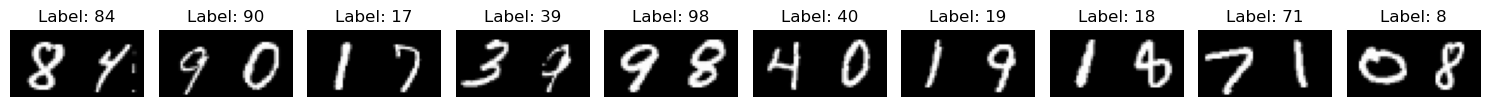

In [ ]:
# 3. Visualize some examples to check merging
# This will be part of your Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i in range(10):
    # Pick random images from the new dataset
    idx = random.randint(0, len(train_dataset_2digits) - 1)
    img, label = train_dataset_2digits[idx]
    
    # PyTorch uses format [Channel, Height, Width]. 
    # Matplotlib needs [Height, Width] for grayscale images, use squeeze()
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()